# Room EQ - Prototype

Below, we illustrate a prototype for our software version of a room-eq device. It does the following:

1. Generates Sine Sweep
2. Listens to Room IR from Sine Sweep
3. Computes Filter Coefficients from Estimated Room IR

I generated functions with Claude based on this [repository](https://github.com/baranovmv/RoomResponse)

In [1]:
# Step 1: Import necessary libraries
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Convolution, FFT, and Windowing functions
from scipy.signal import fftconvolve
from scipy.fft import fft
from numpy import kaiser

# Experimentation
import sys
!{sys.executable} -m pip install sounddevice

import sounddevice as sd

In [2]:
# Step 2: Generate Sweep
#
# A "sine sweep" is a sine wave whose frequency rises over time.
# We use a *logarithmic* sweep (from Farina 2000) because human hearing
# is logarithmic — an octave from 100→200 Hz feels the same "distance"
# as an octave from 1000→2000 Hz, so we want to spend equal time in each.
#
# The sweep goes from frequency f1 (Hz) to f2 (Hz) over T seconds.
# At every moment t, the instantaneous frequency is:
#
#   f(t) = f1 * (f2/f1)^(t/T)
#
# A sine wave needs a *phase* argument, not an instantaneous frequency.
# Phase is the running total of all the angles we've passed through:
#
#   phase(t) = ∫₀ᵗ 2π·f(τ) dτ
#            = 2π · K · (e^(t/L) − 1)
#
# where K and L are just convenient shorthands derived by Farina (see below).

def generate_sweep(f1=20, f2=20000, T=5.0, fs=44100):
    """
    Generate a logarithmic sine sweep.

    Parameters
    ----------
    f1 : float  — start frequency in Hz  (default 20 Hz)
    f2 : float  — end   frequency in Hz  (default 20 000 Hz)
    T  : float  — duration in seconds    (default 5 s)
    fs : int    — sample rate in Hz      (default 44 100 Hz) - CD Quality 

    Returns
    -------
    t      : 1-D array of time values (seconds)
    sweep  : 1-D array of audio samples in [-1, 1]
    """

    # --- angular frequencies (radians per second) ---
    # Multiplying by 2π converts "cycles per second" (Hz) to
    # "radians per second", which is what the math below needs.
    w1 = 2 * np.pi * f1
    w2 = 2 * np.pi * f2

    # --- time axis ---
    # Create one sample for every 1/fs seconds, from t=0 up to (but not
    # including) t=T. e.g. fs=44100 → 44 100 samples per second.
    t = np.arange(0, T, 1.0 / fs)   # shape: (T*fs,)

    # --- Farina's helper constants ---
    # These come straight from evaluating the integral ∫ w1·(w2/w1)^(τ/T) dτ.
    # K has units of radians;  L has units of seconds.
    L = T / np.log(w2 / w1)         # "time scale" of the exponential growth
    K = T * w1 / np.log(w2 / w1)    # = w1 * L  (total phase scale factor)

    # --- instantaneous phase at every time sample ---
    # This is the closed-form result of the integral above.
    # Think of phase as the "angle" of the sine wave at each moment.
    # When phase grows slowly → low frequency.
    # When phase grows quickly → high frequency.
    phase = K * (np.exp(t / L) - 1.0)

    # --- the sweep signal ---
    # A pure sine wave is just sin(phase).  The phase here increases
    # exponentially, so the frequency starts low and rises to f2 at t=T.
    sweep = np.sin(phase)

    return t, sweep


The function above derives from the log sine sweep illustrated in "Simultaneous measurement of impulse response and distortion with a swept-sine technique" from Angelo Farina. Let's go ahead and plot out the waveform and the instant frequency to see how this actually looks like.

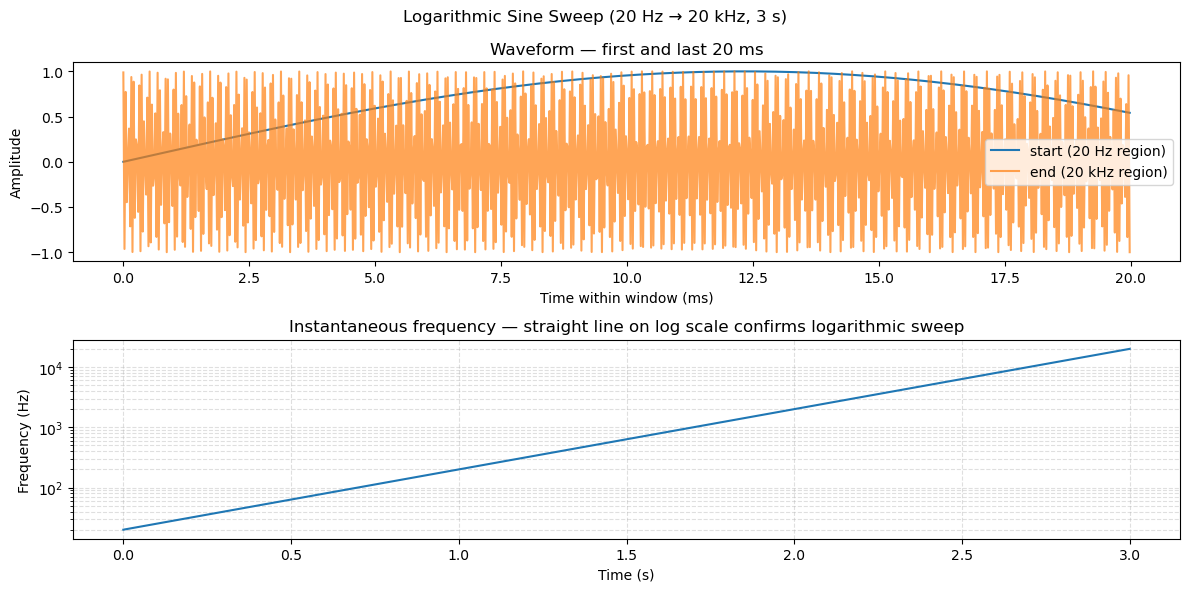

In [3]:
# Generate a 3-second sweep from 20 Hz to 20 000 Hz
t, sweep = generate_sweep(f1=20, f2=20000, T=3.0, fs=44100)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle("Logarithmic Sine Sweep (20 Hz → 20 kHz, 3 s)")

# --- Top plot: the waveform ---
# Plotting all 132 300 samples at once would look like a solid block,
# so we zoom in on the first and last 20 ms to see the actual oscillations.
# At the start the waves are slow (low freq); at the end they are fast (high freq).
ms20 = int(0.020 * 44100)   # number of samples in 20 ms
axes[0].plot(t[:ms20] * 1000, sweep[:ms20], label="start (20 Hz region)")
axes[0].plot(t[-ms20:] * 1000 - t[-ms20] * 1000, sweep[-ms20:],
             label="end (20 kHz region)", alpha=0.7)
axes[0].set_xlabel("Time within window (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveform — first and last 20 ms")
axes[0].legend()

# --- Bottom plot: instantaneous frequency over time ---
# The defining formula for a log sweep is f(t) = f1 * (f2/f1)^(t/T).
# On a log-frequency axis this is a straight line — a good sanity check
# that our sweep is truly logarithmic.
f_inst = 20 * (20000 / 20) ** (t / 3.0)   # Hz at each time sample

axes[1].plot(t, f_inst)
axes[1].set_yscale("log")          # log scale makes the exponential look linear
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("Instantaneous frequency — straight line on log scale confirms logarithmic sweep")
axes[1].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"plots/01_sweep_waveform_and_freq.png", dpi=150, bbox_inches="tight")
plt.show()


We note that the first 20 ms is marked by a slow waveform because we are in the 20 Hz range whereas the end is marked by a fast changing waveform as it is in the 20 kHz range. This checks out.

In [4]:
# Step 3: Generate the Inverse Filter
#
# GOAL: given the sweep we just made, build its "inverse" so that when
# we record the room's response and convolve with this inverse, we get
# the room's impulse response (IR) — i.e. how the room colors sound.
#
# WHY DO WE NEED AN INVERSE?
# If you play a sweep x(t) into a room and record y(t), then:
#
#   y(t) = x(t) convolved with h(t)
#
# where h(t) is the room IR we want.  Convolution has an inverse operation.
# We build x_inv(t) such that:
#
#   x(t) convolved with x_inv(t) = delta(t)   (a perfect impulse)
#
# Then:  y(t) convolved with x_inv(t) = h(t)  ← the room IR.
#
# HOW?  Three steps:
#   1. Reverse the sweep in time.
#   2. Apply an exponential amplitude envelope.
#   3. Normalize so the result has the right scale.

def generate_inverse_sweep(sweep, f1=20, f2=20000, T=5.0, fs=44100):
    """
    Build the inverse filter for a logarithmic sine sweep.

    Parameters
    ----------
    sweep : 1-D array  — the sweep produced by generate_sweep()
    f1, f2, T, fs      — same parameters used in generate_sweep()

    Returns
    -------
    inv : 1-D array — the inverse filter (same length as sweep)
    """

    N = len(sweep)   # total number of samples in the sweep

    # -------------------------------------------------------------------------
    # STEP 3a: Taper the edges of the sweep with a Kaiser window.
    #
    # An abrupt start or stop is like multiplying the sweep by a rectangle.
    # In the frequency domain a rectangle becomes a "sinc" shape with ripples
    # that spread fake energy across all frequencies — called spectral leakage.
    # Tapering the edges smoothly to zero removes those sharp corners and
    # eliminates the leakage.  We use a Kaiser window, which lets us tune
    # exactly how aggressive the taper is (higher beta = steeper roll-off).
    #
    # We only apply the window to the first and last ~2500 samples (~57 ms),
    # leaving the body of the sweep untouched.
    # We could use another form of window (e.g. Hanning, Hamming, Blackman), but this
    # is based on the repository I looked at. This is open for debate.
    # -------------------------------------------------------------------------

    sweep = sweep.copy()   # don't modify the original array

    # Taper the START — take the left half of a Kaiser window and multiply
    # it onto the beginning of the sweep so it fades in from 0.
    win_start = kaiser(2500, beta=16)[:1250]   # beta=16: fairly aggressive taper
    # The window is 2500 samples long, but we only use the first half (1250 samples) to taper the start of the sweep.
    # We can imagine this as a "fade in" that gradually increases the amplitude from 0 to 1 over the first 1250 samples.
    sweep[:1250] *= win_start

    # Taper the END — take the right half of a Kaiser window and multiply
    # it onto the end of the sweep so it fades out to 0.
    # We also use 1250 samples here, but for the second half of the window.
    win_end = kaiser(2500, beta=14)[1250:]     # beta=14: slightly softer taper
    sweep[-1250:] *= win_end

    # -------------------------------------------------------------------------
    # STEP 3b: Reverse the sweep in time.
    #
    # A log sweep spends equal *time* at each octave, but higher octaves
    # have more *cycles* per second, so high frequencies carry more energy.
    # Reversing alone would give a filter whose frequency-domain magnitude
    # is the mirror image of the sweep's — useful, but not yet flat.
    # -------------------------------------------------------------------------

    inv = sweep[::-1].copy()   # [::-1] is Python shorthand for "reverse"

    # -------------------------------------------------------------------------
    # STEP 3c: Apply an exponential amplitude envelope to the reversed sweep.
    #
    # Farina shows that the correct inverse filter for a log sweep needs its
    # amplitude to *decrease* at 6 dB per octave as you move along the
    # reversed signal (which corresponds to *increasing* frequency in the
    # original sweep direction).
    #
    # WHY 6 dB/octave?
    # The log sweep devotes equal time to each octave, but each octave has
    # twice as many Hz as the previous one, so the sweep "moves faster"
    # through higher octaves — meaning it delivers more energy there.
    # The 6 dB/octave roll-off exactly cancels that imbalance, so the
    # combined response (sweep ⊛ inverse) is flat across all frequencies.
    #
    # We express "6 dB per octave" as a linear decay factor per sample:
    #
    #   total dB drop = -6 * log2(f2/f1)   (number of octaves × -6 dB)
    #   kend          = 10^(total_dB / 20)  (convert dB → linear amplitude)
    #   k             = ln(kend) / N        (decay rate per sample)
    #
    # Then the envelope at sample n is exp(n * k).
    # -------------------------------------------------------------------------

    num_octaves = np.log2(f2 / f1)               # e.g. 20→20000 Hz ≈ 9.97 octaves
    total_dB    = -6.0 * num_octaves              # e.g. ≈ -59.8 dB total drop
    kend        = 10 ** (total_dB / 20.0)         # linear amplitude at the last sample
    k           = np.log(kend) / N               # decay rate (negative number) per sample

    # Build the envelope: one value per sample, starting at 1.0 and
    # decaying exponentially to kend by the last sample.
    n        = np.arange(N)
    envelope = np.exp(n * k)                      # shape: (N,)
    # The envelope starts at 1.0 (when n=0) and decays to kend (when n=N-1).

    inv *= envelope   # apply envelope to the reversed sweep
    # The goal is to offset the imbalance of energy across frequencies.
    # If we skip this, our IR will not be not flat.

    # -------------------------------------------------------------------------
    # STEP 3d: Normalize the inverse filter.
    #
    # If we convolve the sweep with its inverse we should get a perfect
    # impulse (a single spike).  In practice the amplitude of that spike
    # depends on the energy of our signals, so we need to scale inv so the
    # spike height is exactly 1.
    #
    # We compute the convolution, look at its amplitude near the middle of
    # the frequency axis (quarter-way through the FFT ≈ mid-band), and
    # divide by that value.  This is a simple, practical normalization.
    # I believe this is a naive approach taken by that repository that was sufficient.
    # We could always do a more rigorous approach.
    # -------------------------------------------------------------------------

    test_conv  = fftconvolve(inv, sweep)          # should be ≈ impulse after normalization
    F          = fft(test_conv)                   # take it to the frequency domain
    mid_bin    = round(len(F) / 4)               # pick a mid-band frequency bin
    scale      = np.abs(F[mid_bin])              # amplitude at that bin

    inv /= scale   # divide so mid-band amplitude becomes 1

    return inv


For further clarification, below we plot how the Kaiser window affects the sweep:

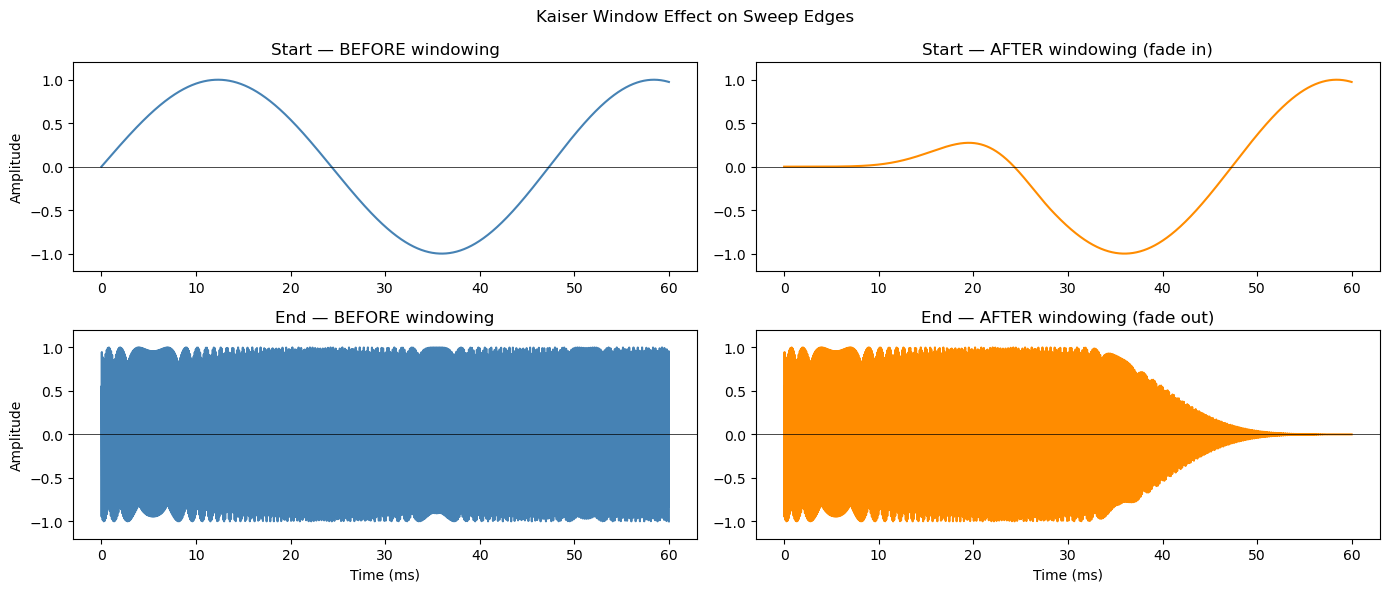

In [5]:
t, sweep_raw = generate_sweep(f1=20, f2=20000, T=3.0, fs=44100)

# Build the windowed version without going through the full inverse pipeline
sweep_windowed = sweep_raw.copy()
win_start = kaiser(2500, beta=16)[:1250]
win_end   = kaiser(2500, beta=14)[1250:]
sweep_windowed[:1250]  *= win_start
sweep_windowed[-1250:] *= win_end

# How many samples to show at each edge (first/last 60 ms)
edge = int(0.060 * 44100)

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Kaiser Window Effect on Sweep Edges")

# --- Top row: START of sweep ---
axes[0, 0].plot(t[:edge] * 1000, sweep_raw[:edge], color="steelblue")
axes[0, 0].set_title("Start — BEFORE windowing")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].set_ylim(-1.2, 1.2)
axes[0, 0].axhline(0, color="k", lw=0.5)

axes[0, 1].plot(t[:edge] * 1000, sweep_windowed[:edge], color="darkorange")
axes[0, 1].set_title("Start — AFTER windowing (fade in)")
axes[0, 1].set_ylim(-1.2, 1.2)
axes[0, 1].axhline(0, color="k", lw=0.5)

# --- Bottom row: END of sweep ---
t_end_ms = (t[-edge:] - t[-edge]) * 1000   # re-zero so x-axis starts at 0

axes[1, 0].plot(t_end_ms, sweep_raw[-edge:], color="steelblue")
axes[1, 0].set_title("End — BEFORE windowing")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylim(-1.2, 1.2)
axes[1, 0].axhline(0, color="k", lw=0.5)

axes[1, 1].plot(t_end_ms, sweep_windowed[-edge:], color="darkorange")
axes[1, 1].set_title("End — AFTER windowing (fade out)")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylim(-1.2, 1.2)
axes[1, 1].axhline(0, color="k", lw=0.5)

plt.tight_layout()
plt.savefig(f"plots/02_kaiser_window_effect.png", dpi=150, bbox_inches="tight")
plt.show()


Below, we illustrate how the the 6 dB/octave roll-off envelope attempts to correct the imbalance from the sine sweep delivering more energy to higher octaves.

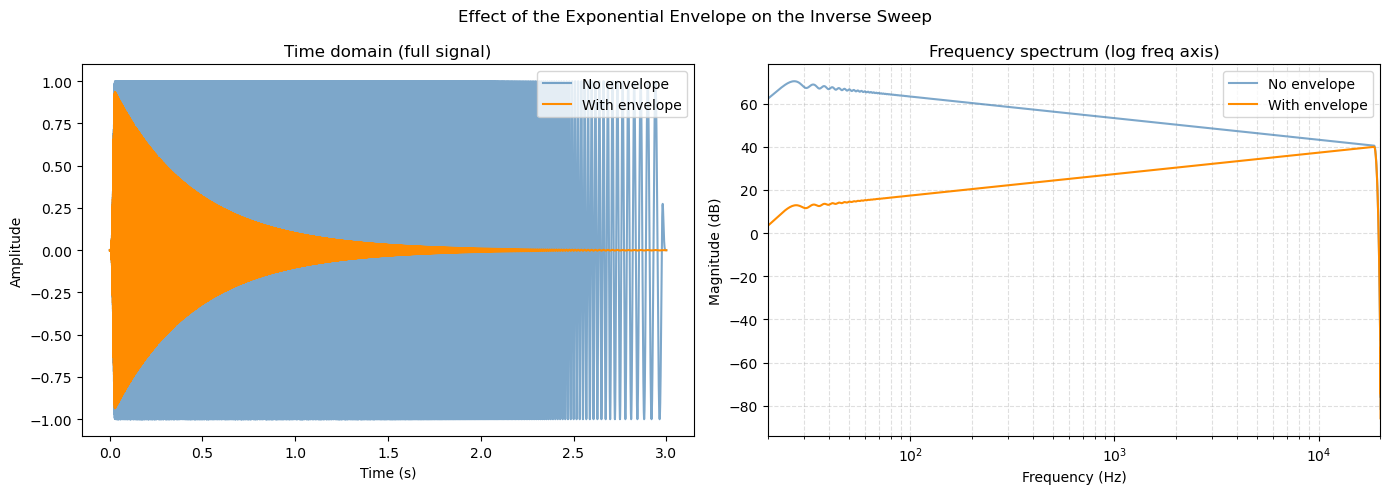

In [6]:
t, sweep_raw = generate_sweep(f1=20, f2=20000, T=3.0, fs=44100)
N = len(sweep_raw)

# --- Build windowed sweep (Kaiser taper applied) ---
sweep_w = sweep_raw.copy()
sweep_w[:1250]  *= kaiser(2500, beta=16)[:1250]
sweep_w[-1250:] *= kaiser(2500, beta=14)[1250:]

# --- Reversed sweep WITHOUT envelope ---
inv_no_env = sweep_w[::-1].copy()

# --- Reversed sweep WITH envelope ---
num_octaves = np.log2(20000 / 20)
total_dB    = -6.0 * num_octaves
kend        = 10 ** (total_dB / 20.0)
k           = np.log(kend) / N
envelope    = np.exp(np.arange(N) * k)   # decays from 1.0 → kend

inv_with_env = inv_no_env * envelope

# Frequency axis for spectrum plots (positive frequencies only, up to fs/2)
freqs = np.fft.rfftfreq(N, d=1.0/44100)

# Magnitude spectrum of each (in dB so the slope is easy to read)
def mag_db(x):
    spec = np.abs(np.fft.rfft(x))
    spec = np.maximum(spec, 1e-12)          # avoid log(0)
    return 20 * np.log10(spec)

db_no_env   = mag_db(inv_no_env)
db_with_env = mag_db(inv_with_env)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of the Exponential Envelope on the Inverse Sweep")

# --- Left: time domain — shows the amplitude taper ---
# The envelope makes the inverse grow quiet toward the end.
# Remember: the start of inv = high frequencies of original sweep.
axes[0].plot(t, inv_no_env,   color="steelblue",  label="No envelope", alpha=0.7)
axes[0].plot(t, inv_with_env, color="darkorange",  label="With envelope")
axes[0].set_title("Time domain (full signal)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

# --- Right: frequency spectrum — shows the 6 dB/octave slope ---
# Without envelope: spectrum is roughly flat (just the reversed sweep).
# With envelope:    spectrum rises at ~6 dB/octave toward high freqs,
#                   which will cancel the sweep's 1/f drop when convolved.
axes[1].semilogx(freqs, db_no_env,   color="steelblue", label="No envelope",   alpha=0.7)
axes[1].semilogx(freqs, db_with_env, color="darkorange", label="With envelope")
axes[1].set_title("Frequency spectrum (log freq axis)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].set_xlim(20, 20000)
axes[1].legend()
axes[1].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"plots/03_envelope_effect.png", dpi=150, bbox_inches="tight")
plt.show()


Now, we illustrate the effects of normalizing our inverted sine sweep by the mid-range frequencies.

Normalization scale factor: 10579.8396
  → every sample of inv will be divided by 10579.8396


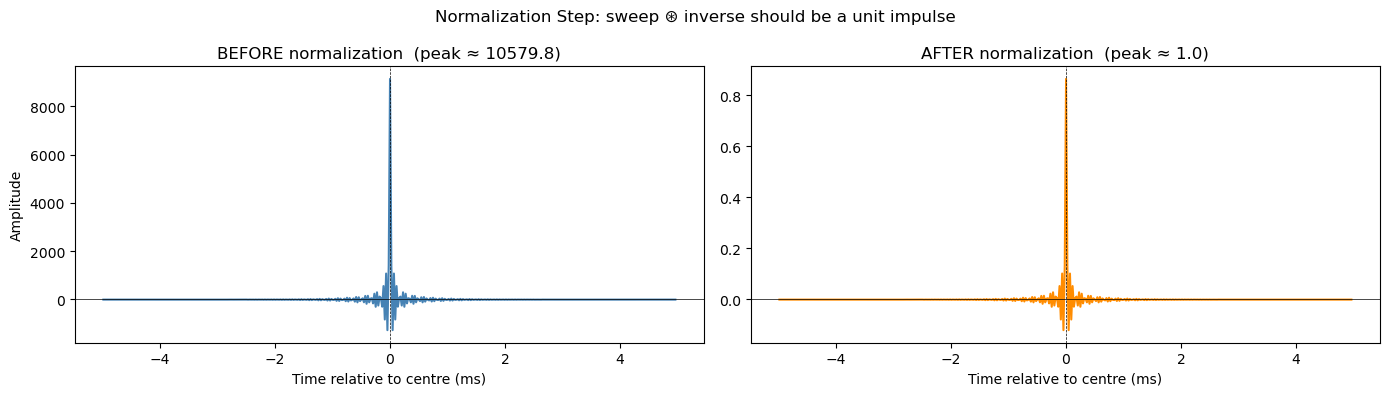

In [7]:
t, sweep_raw = generate_sweep(f1=20, f2=20000, T=3.0, fs=44100)
N = len(sweep_raw)

# Build windowed + enveloped inverse (pre-normalization)
sweep_w = sweep_raw.copy()
sweep_w[:1250]  *= kaiser(2500, beta=16)[:1250]
sweep_w[-1250:] *= kaiser(2500, beta=14)[1250:]

inv = sweep_w[::-1].copy()
num_octaves = np.log2(20000 / 20)
kend        = 10 ** ((-6.0 * num_octaves) / 20.0)
k           = np.log(kend) / N
inv        *= np.exp(np.arange(N) * k)

# --- Before normalization ---
inv_before = inv.copy()

# --- Compute the normalization scale factor ---
# Convolve inv with the sweep: if inv is a perfect inverse, this should be
# a single spike (delta function). The height of that spike tells us by
# what factor we need to divide inv so the spike lands at exactly 1.
test_conv = fftconvolve(inv, sweep_w)
F         = fft(test_conv)
mid_bin   = round(len(F) / 4)
scale     = np.abs(F[mid_bin])
print(f"Normalization scale factor: {scale:.4f}")
print(f"  → every sample of inv will be divided by {scale:.4f}")

# --- After normalization ---
inv_after = inv / scale

# -----------------------------------------------------------------------
# Plot 1: the convolution result (sweep ⊛ inv) before and after scaling.
# Before: the spike peak equals `scale` (some arbitrary large number).
# After:  the spike peak is 1.0 — a true unit impulse.
# -----------------------------------------------------------------------
conv_before = fftconvolve(inv_before, sweep_w)
conv_after  = fftconvolve(inv_after,  sweep_w)

# The spike sits at the centre of the convolved signal (length = 2N-1).
# Zoom to a ±5 ms window around it so we can actually see the spike shape.
centre   = len(conv_before) // 2
zoom     = int(0.005 * 44100)   # 5 ms in samples
t_zoom   = np.arange(-zoom, zoom) / 44100 * 1000   # ms

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Normalization Step: sweep ⊛ inverse should be a unit impulse")

axes[0].plot(t_zoom, conv_before[centre-zoom : centre+zoom], color="steelblue")
axes[0].set_title(f"BEFORE normalization  (peak ≈ {scale:.1f})")
axes[0].set_xlabel("Time relative to centre (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].axvline(0, color="k", lw=0.5, ls="--")

axes[1].plot(t_zoom, conv_after[centre-zoom : centre+zoom], color="darkorange")
axes[1].set_title("AFTER normalization  (peak ≈ 1.0)")
axes[1].set_xlabel("Time relative to centre (ms)")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(0, color="k", lw=0.5, ls="--")

plt.tight_layout()
plt.savefig(f"plots/04_normalization_effect.png", dpi=150, bbox_inches="tight")
plt.show()


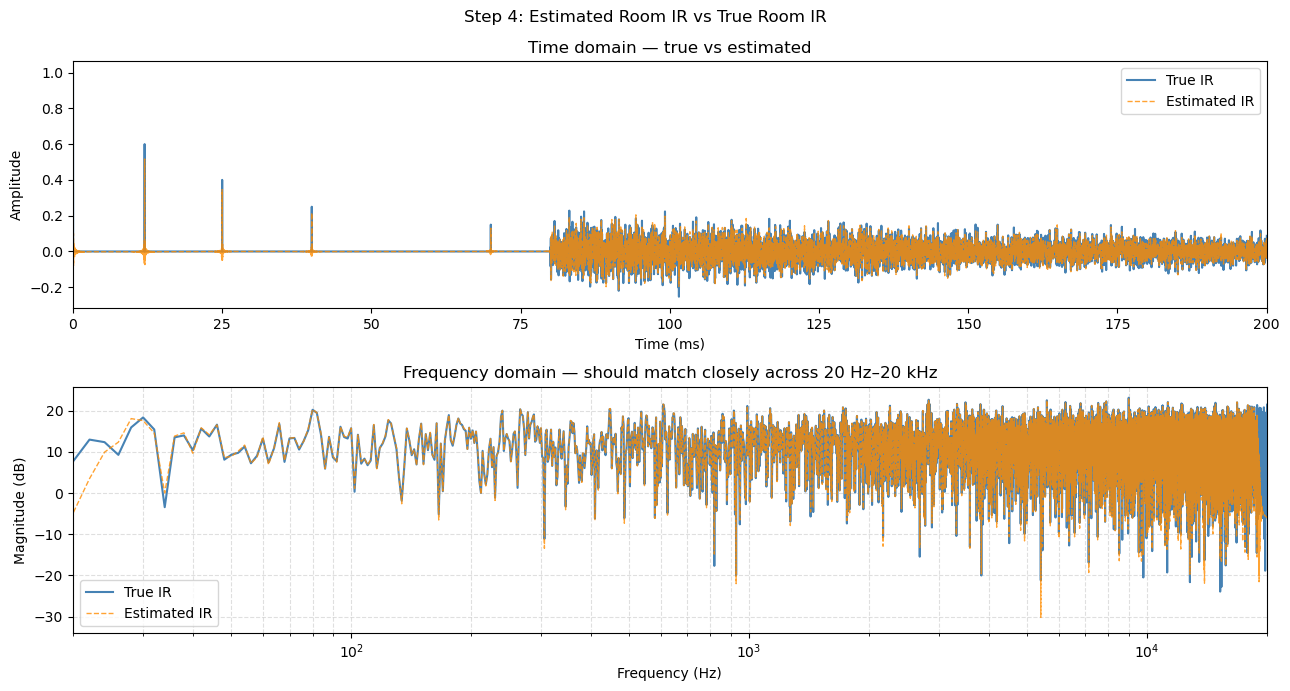

In [8]:
# Step 4: Estimate the Room Impulse Response (IR)
#
# RECAP OF WHAT WE HAVE SO FAR:
#   sweep  — the signal we play into the room (x)
#   inv    — the inverse filter we built in Step 3 (x_inv)
#
# NOW:
#   When we play the sweep into a room and record what comes back, we get:
#
#       recording(t)  =  sweep(t)  convolved with  room_IR(t)
#
#   The room "stamps" its fingerprint on every sound that passes through it
#   (reflections, resonances, absorptions) — that's what convolution models.
#
#   To recover the room IR we simply convolve the recording with our inverse:
#
#       recording(t)  convolved with  inv(t)
#     = sweep(t) convolved with room_IR(t) convolved with inv(t)
#     = room_IR(t)  convolved with  [sweep convolved with inv]
#     = room_IR(t)  convolved with  delta(t)      ← Step 3 guarantee
#     = room_IR(t)                                ← the true room IR!
#
# SIMULATION:
#   We don't have a real room to record in yet, so we invent a fake room IR
#   and use it to produce a synthetic recording.  If our pipeline is correct,
#   convolving that recording with inv should give back the fake IR.

# ── 4a. Build a fake room IR ──────────────────────────────────────────────
# A real room IR is a sharp spike (direct sound) followed by many decaying
# echoes (reflections off walls, floor, ceiling).  We model this simply:
#   • one direct spike at t=0
#   • a few discrete reflections at fixed delays, each quieter than the last
#   • exponential decay envelope to simulate absorption

fs = 44100
ir_len = int(0.5 * fs)          # 0.5 seconds is long enough for most rooms
true_ir = np.zeros(ir_len)

# Direct sound — arrives first, loudest
true_ir[0] = 1.0

# Early reflections — discrete echoes from nearby surfaces
reflections = [
    (int(0.012 * fs), 0.6),    # 12 ms delay, 60% amplitude
    (int(0.025 * fs), 0.4),    # 25 ms delay, 40% amplitude
    (int(0.040 * fs), 0.25),   # 40 ms delay, 25% amplitude
    (int(0.070 * fs), 0.15),   # 70 ms delay, 15% amplitude
]
for delay, gain in reflections:
    true_ir[delay] = gain

# Late reverberation tail — dense exponential decay after ~80 ms
rng = np.random.default_rng(42)                     # fixed seed for reproducibility
tail_start = int(0.080 * fs)
tail       = rng.standard_normal(ir_len - tail_start)
decay      = np.exp(-np.arange(len(tail)) / (0.15 * fs))   # 150 ms decay constant
true_ir[tail_start:] += 0.08 * tail * decay

# ── 4b. Simulate recording the room ──────────────────────────────────────
# In reality: play the sweep through a speaker, record with a microphone.
# In simulation: convolve the sweep with the true IR.
t, sweep_raw = generate_sweep(f1=20, f2=20000, T=3.0, fs=fs)

# Apply Kaiser windows (same as in generate_inverse_sweep)
sweep_w = sweep_raw.copy()
sweep_w[:1250]  *= kaiser(2500, beta=16)[:1250]
sweep_w[-1250:] *= kaiser(2500, beta=14)[1250:]

recording = fftconvolve(sweep_w, true_ir)   # this is what a microphone would capture

# ── 4c. Generate the inverse filter ──────────────────────────────────────
inv = generate_inverse_sweep(sweep_raw, f1=20, f2=20000, T=3.0, fs=fs)

# ── 4d. Recover the IR by convolving recording with inv ──────────────────
# This is the core estimation step.
# recording ⊛ inv  =  (sweep ⊛ true_ir) ⊛ inv
#                  =  true_ir ⊛ (sweep ⊛ inv)
#                  =  true_ir ⊛ delta
#                  =  true_ir
full_result  = fftconvolve(recording, inv)

# The convolution output is longer than the IR (length = len(recording) + len(inv) - 1).
# The IR lives in the first ir_len samples of the second half of the result,
# aligned around the centre.  Trim to the first ir_len samples from the peak.
peak         = np.argmax(np.abs(full_result))
estimated_ir = full_result[peak : peak + ir_len] # Subset of the convolution result that should match the true IR, not the entire convolution output.

# ── 4e. Plot true vs estimated IR ─────────────────────────────────────────
t_ir = np.arange(ir_len) / fs * 1000   # time axis in ms

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
fig.suptitle("Step 4: Estimated Room IR vs True Room IR")

# Top — overlay both IRs in the time domain
# If the pipeline is correct they should line up closely.
axes[0].plot(t_ir, true_ir,      color="steelblue",  label="True IR",      lw=1.5)
axes[0].plot(t_ir, estimated_ir, color="darkorange",  label="Estimated IR", lw=1, alpha=0.8, ls="--")
axes[0].set_title("Time domain — true vs estimated")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].set_xlim(0, 200)   # zoom to first 200 ms where the action is

# Bottom — magnitude spectrum of both IRs (in dB)
# A flat spectrum means the room affects all frequencies equally.
# Peaks/dips show resonances or absorptions at particular frequencies.
def mag_db(x):
    spec = np.abs(np.fft.rfft(x))
    return 20 * np.log10(np.maximum(spec, 1e-12))

freqs = np.fft.rfftfreq(ir_len, d=1.0/fs)
axes[1].semilogx(freqs, mag_db(true_ir),      color="steelblue",  label="True IR",      lw=1.5)
axes[1].semilogx(freqs, mag_db(estimated_ir), color="darkorange",  label="Estimated IR", lw=1, alpha=0.8, ls="--")
axes[1].set_title("Frequency domain — should match closely across 20 Hz–20 kHz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].set_xlim(20, 20000)
axes[1].legend()
axes[1].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"plots/05_simulated_ir_true_vs_estimated.png", dpi=150, bbox_inches="tight")
plt.show()


Now, that we know this works on a perfect example, let's try it with my own bedroom and my Klipsch Reference R-41M speakers with a Blue Snowball Microphone.

In [11]:
# ── Device discovery ──────────────────────────────────────────────────────
# Run this cell first to find the index numbers for your two devices:
#   • Blue Snowball  → look for "Snowball" in the INPUT  columns
#   • Klipsch BT     → look for your speaker name in the OUTPUT columns
#
# Write down the two index numbers — you'll need them in the next cell.

sd._terminate() 
sd._initialize()                                                                                                                                                  
print(sd.query_devices())
print()
print(f"Default input  device: {sd.default.device[0]}")
print(f"Default output device: {sd.default.device[1]}")


  0  Christian.  Microphone, Core Audio (1 in, 0 out)
  1 Blue Snowball, Core Audio (2 in, 0 out)
  2 BlackHole 2ch, Core Audio (2 in, 2 out)
< 3 External Headphones, Core Audio (0 in, 2 out)
> 4 MacBook Pro Microphone, Core Audio (1 in, 0 out)
  5 MacBook Pro Speakers, Core Audio (0 in, 2 out)

Default input  device: 4
Default output device: 3


In [ ]:
# ── Real room measurement ─────────────────────────────────────────────────
#
# BEFORE RUNNING:
#   1. Fill in the device indices from the cell above.
#   2. Set VOLUME to something low (~0.3) first and raise gradually.
#      Ear protection recommended if you crank it.
#   3. Place the Blue Snowball roughly at your listening position,
#      pointing toward the speakers.

INPUT_DEVICE  = 1     # ← Blue Snowball index from the cell above
OUTPUT_DEVICE = 3     # ← Klipsch Bluetooth index from the cell above

VOLUME = 0.5          # overall playback level: 0.0 (silent) → 1.0 (full)

# Sweep parameters — staying within the R-41M's rated range.
# We avoid going below 80 Hz to protect the woofer from over-excursion.
F1 = 80       # Hz — start of sweep
F2 = 18000    # Hz — end of sweep
T  = 5.0      # seconds — longer sweep = better SNR
FS = 44100    # Hz — sample rate (Blue Snowball native rate)

# Extra silence (seconds) recorded before and after the sweep.
# Bluetooth can delay playback by up to ~300 ms; the pre-pad absorbs that.
# The post-pad captures the reverb tail after the sweep ends.
PRE_PAD  = 1.0   # seconds of silence before sweep
POST_PAD = 1.0   # seconds of silence after sweep  (room reverb tail)

# ── Build the sweep ───────────────────────────────────────────
t_sweep, sweep_raw = generate_sweep(f1=F1, f2=F2, T=T, fs=FS)

# Pad with silence so Bluetooth latency doesn't clip the start of the sweep
silence_pre  = np.zeros(int(PRE_PAD  * FS))
silence_post = np.zeros(int(POST_PAD * FS))
playback     = np.concatenate([silence_pre, sweep_raw * VOLUME, silence_post])

# sounddevice expects a 2-D array: (samples, channels).  We play mono.
playback_2d = playback.reshape(-1, 1)

total_samples = len(playback)
print(f"Playing {total_samples/FS:.1f} s of audio  ({total_samples} samples)")
print("Recording simultaneously with Blue Snowball...")

# ── Simultaneous play + record ────────────────────────────────────────────
# sd.playrec plays through OUTPUT_DEVICE and records from INPUT_DEVICE at
# the same time.  device=(input, output) is a tuple of the two device indices.
recording_2d = sd.playrec(
    playback_2d,
    samplerate = FS,
    channels   = 1,                              # mono mic recording
    device     = (INPUT_DEVICE, OUTPUT_DEVICE),  # (input, output) tuple
    dtype      = "float32",
)
sd.wait()   # block until playback + recording finishes

recording = recording_2d[:, 0]   # flatten to 1-D array
print("Done. Recording shape:", recording.shape)

# Quick sanity check — plot the raw recording so we can see the sweep arrived.
plt.figure(figsize=(13, 3))
t_rec = np.arange(len(recording)) / FS
plt.plot(t_rec, recording, lw=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw microphone recording — you should see the sweep envelope in the middle")
plt.tight_layout()
plt.show()


Playing 7.0 s of audio  (308700 samples)
Recording simultaneously with Blue Snowball...


PortAudioError: Error querying device 6

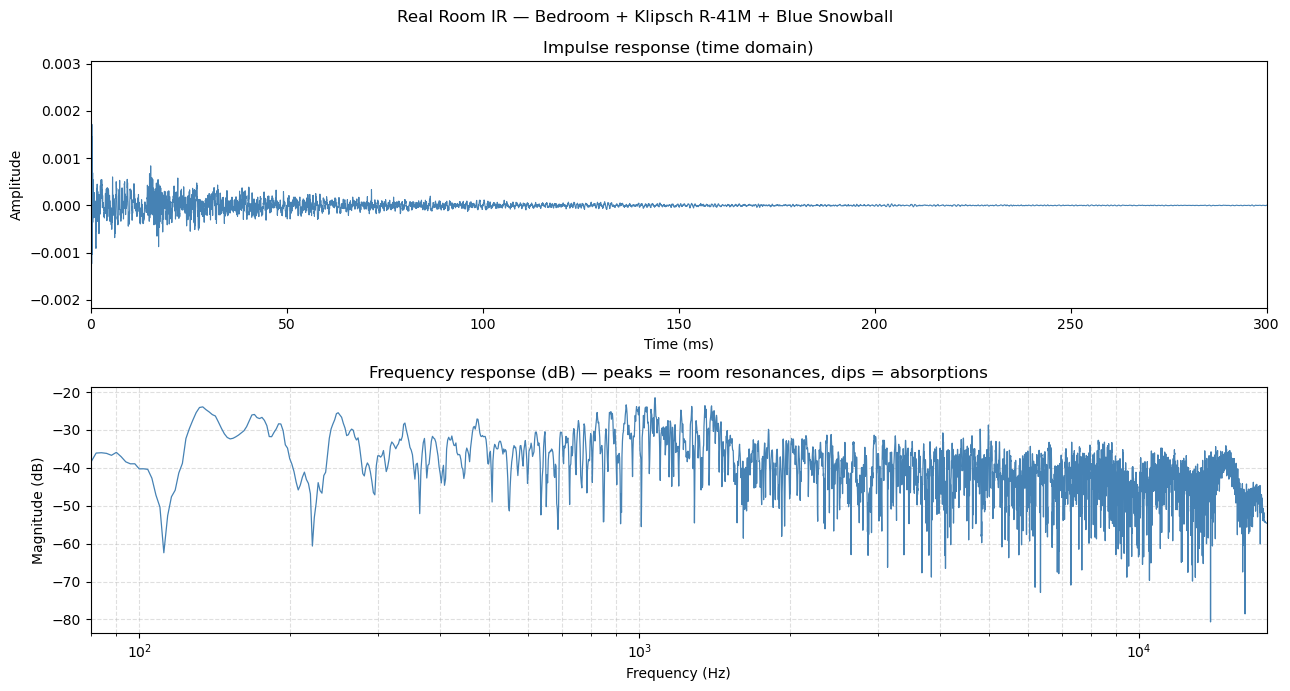

In [ ]:
# ── Estimate IR from real recording ──────────────────────────────────────
# Same pipeline as the simulation in Step 4, now using the real mic signal.

IR_LEN = int(0.5 * FS)   # capture up to 500 ms of room IR

inv = generate_inverse_sweep(sweep_raw, f1=F1, f2=F2, T=T, fs=FS)

full_result  = fftconvolve(recording, inv)
peak         = np.argmax(np.abs(full_result))
room_ir      = full_result[peak : peak + IR_LEN]

t_ir = np.arange(IR_LEN) / FS * 1000   # ms

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
fig.suptitle("Real Room IR — Bedroom + Klipsch R-41M + Blue Snowball")

# Time domain — the spike structure reveals the room's reflection pattern
axes[0].plot(t_ir, room_ir, lw=0.8, color="steelblue")
axes[0].set_title("Impulse response (time domain)")
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, 300)

# Frequency domain — peaks and dips show how the room colours each frequency
axes[1].semilogx(
    np.fft.rfftfreq(IR_LEN, d=1.0/FS),
    20 * np.log10(np.maximum(np.abs(np.fft.rfft(room_ir)), 1e-12)),
    lw=0.9, color="steelblue"
)
axes[1].set_title("Frequency response (dB) — peaks = room resonances, dips = absorptions")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].set_xlim(F1, F2)
axes[1].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"plots/06_real_room_ir.png", dpi=150, bbox_inches="tight")
plt.show()


Detected time offset: 75437 samples  (1710.6 ms)
Amplitude scale factor: 0.9876


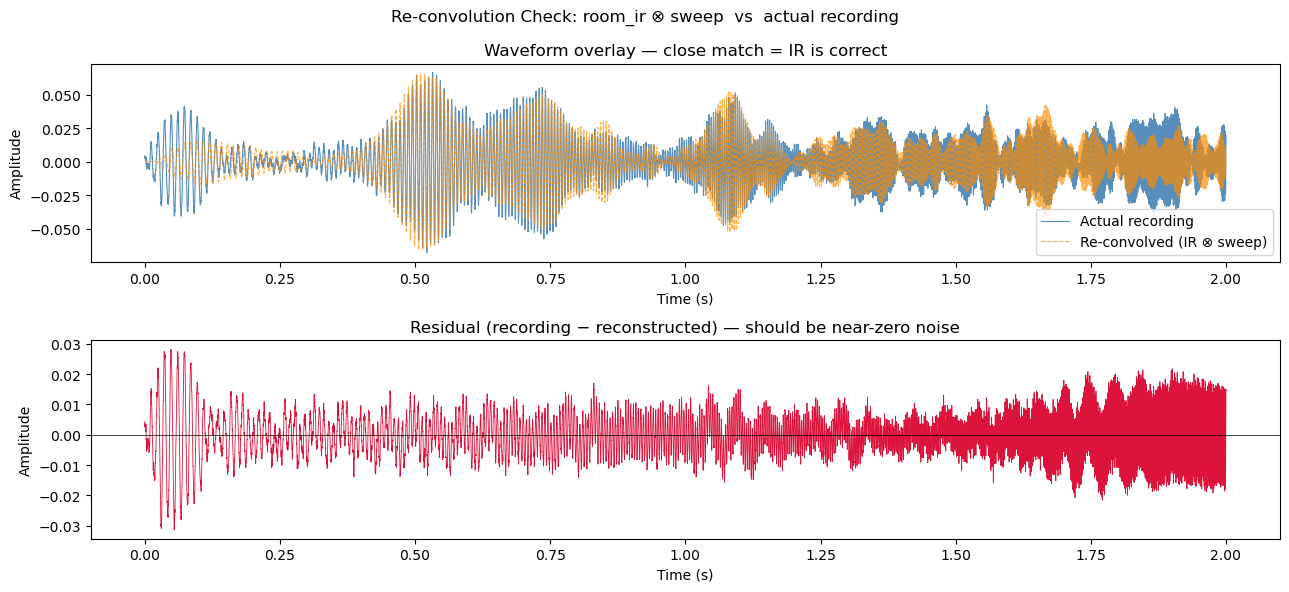

Residual error: -7.1 dB below recording level
(< -20 dB is generally acceptable)

RT60 = 499 ms


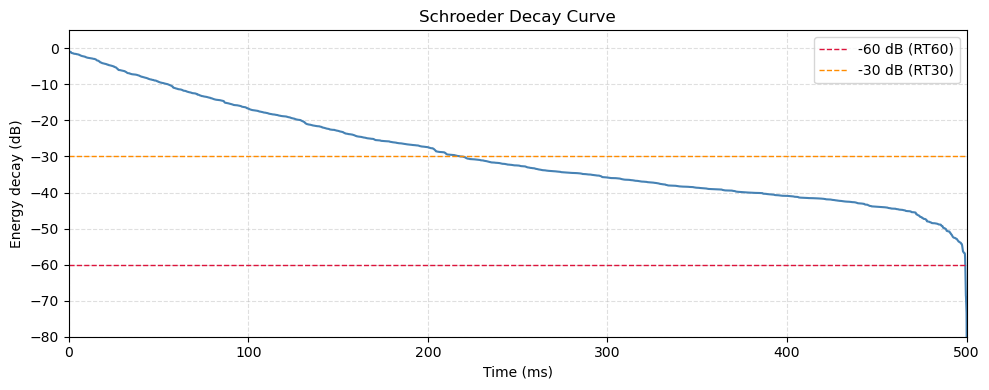

In [ ]:
# ── IR Validation ──────────────────────────────────────────────────
#
# TWO CHECKS:
#
# 1. RE-CONVOLUTION TEST
#    If our estimated IR is correct, then:
#        room_ir ⊗ sweep  ≈  original recording
#    The two signals won't start at the same time (Bluetooth delay + pre-pad
#    silence shift the recording forward), so we use cross-correlation to find
#    the exact sample offset before comparing.
#
# 2. RT60 (Reverberation Time)
#    How long the room takes to decay 60 dB. A bedroom is typically 150-400 ms.

# ── Check 1: Re-convolution ──────────────────────────────────────────

# Window the sweep the same way generate_inverse_sweep does
sweep_w = sweep_raw.copy()
sweep_w[:1250]  *= kaiser(2500, beta=16)[:1250]
sweep_w[-1250:] *= kaiser(2500, beta=14)[1250:]

# Convolve estimated IR with the sweep to reconstruct what the mic should have heard
reconstructed = fftconvolve(room_ir, sweep_w)

# Find the time offset between recording and reconstructed using cross-correlation.
# Cross-correlation slides one signal over the other and finds where they match best.
# The index of the peak tells us how many samples the recording is shifted forward.
xcorr  = fftconvolve(recording, reconstructed[::-1])   # cross-correlation
offset = np.argmax(np.abs(xcorr)) - (len(reconstructed) - 1)
# offset > 0 means recording starts later than reconstructed (expected: BT delay + pre-pad)
print(f"Detected time offset: {offset} samples  ({offset/FS*1000:.1f} ms)")

# Trim both to a common aligned window for comparison
if offset >= 0:
    rec_aligned   = recording[offset:]
    recon_aligned = reconstructed
else:
    rec_aligned   = recording
    recon_aligned = reconstructed[-offset:]

compare_len = min(len(rec_aligned), len(recon_aligned))
rec_aligned   = rec_aligned[:compare_len]
recon_aligned = recon_aligned[:compare_len]

# Scale reconstructed to match the recording's amplitude.
# The mic gain and speaker volume mean the absolute levels differ;
# we find the least-squares scale factor that minimises the residual.
scale = np.dot(rec_aligned, recon_aligned) / (np.dot(recon_aligned, recon_aligned) + 1e-12)
recon_scaled = recon_aligned * scale
print(f"Amplitude scale factor: {scale:.4f}")

t_cmp = np.arange(compare_len) / FS
zoom_n = int(2.0 * FS)   # show 2 seconds

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle("Re-convolution Check: room_ir ⊗ sweep  vs  actual recording")

axes[0].plot(t_cmp[:zoom_n], rec_aligned[:zoom_n],
             color="steelblue",  lw=0.8, label="Actual recording", alpha=0.9)
axes[0].plot(t_cmp[:zoom_n], recon_scaled[:zoom_n],
             color="darkorange", lw=0.8, label="Re-convolved (IR ⊗ sweep)", alpha=0.7, ls="--")
axes[0].set_title("Waveform overlay — close match = IR is correct")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

residual = rec_aligned - recon_scaled
axes[1].plot(t_cmp[:zoom_n], residual[:zoom_n], color="crimson", lw=0.6)
axes[1].set_title("Residual (recording − reconstructed) — should be near-zero noise")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].axhline(0, color="k", lw=0.5)

plt.tight_layout()
plt.savefig(f"plots/07_reconvolution_check.png", dpi=150, bbox_inches="tight")
plt.show()

rms_rec      = np.sqrt(np.mean(rec_aligned**2))
rms_residual = np.sqrt(np.mean(residual**2))
error_db     = 20 * np.log10(rms_residual / (rms_rec + 1e-12))
print(f"Residual error: {error_db:.1f} dB below recording level")
print("(< -20 dB is generally acceptable)")

# ── Check 2: RT60 via Schroeder curve ─────────────────────────────────

# Schroeder curve: cumulative energy of the IR integrated from back to front.
# This gives a smooth decay curve even when the IR is noisy.
energy       = room_ir ** 2
schroeder    = np.cumsum(energy[::-1])[::-1]
schroeder_db = 10 * np.log10(schroeder / (schroeder[0] + 1e-12))

t_ir_ms  = np.arange(IR_LEN) / FS * 1000
below_60 = np.where(schroeder_db < -60)[0]
below_30 = np.where(schroeder_db < -30)[0]

if len(below_60) > 0:
    print(f"\nRT60 = {t_ir_ms[below_60[0]]:.0f} ms")
elif len(below_30) > 0:
    rt30 = t_ir_ms[below_30[0]]
    print(f"\nRT30 = {rt30:.0f} ms  →  estimated RT60 ≈ {rt30*2:.0f} ms")
else:
    print("\nCould not determine RT60 — IR window may be too short")

plt.figure(figsize=(10, 4))
plt.plot(t_ir_ms, schroeder_db, color="steelblue")
plt.axhline(-60, color="crimson",    ls="--", lw=1, label="-60 dB (RT60)")
plt.axhline(-30, color="darkorange", ls="--", lw=1, label="-30 dB (RT30)")
plt.xlabel("Time (ms)")
plt.ylabel("Energy decay (dB)")
plt.title("Schroeder Decay Curve")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.xlim(0, IR_LEN / FS * 1000)
plt.ylim(-80, 5)
plt.tight_layout()
plt.savefig(f"plots/08_schroeder_decay.png", dpi=150, bbox_inches="tight")
plt.show()


Next Steps: Derive Coefficients 